Imports + basic config

In [1]:
!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension


usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert run server troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


In [2]:
import os
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
# CHANGE this if you used a different drive / folder
DATA_ROOT = Path(r"D:\datasets\chest_xray")  # or r"C:\datasets\chest_xray"

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "val"
TEST_DIR  = DATA_ROOT / "test"

print("Train dir exists:", TRAIN_DIR.exists())
print("Val dir exists:", VAL_DIR.exists())
print("Test dir exists:", TEST_DIR.exists())


Train dir exists: True
Val dir exists: True
Test dir exists: True


Transforms and ImageFolder datasets

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # grayscale-like normalization
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(VAL_DIR, transform=test_tfms)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=test_tfms)

print("Classes:", train_ds.classes)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))


Classes: ['NORMAL', 'PNEUMONIA']
Train size: 4832
Val size: 396
Test size: 624


Create DataLoaders

In [5]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

len(train_loader), len(val_loader), len(test_loader)


(302, 25, 39)

Baseline Model: ResNet-18

In [6]:
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 2

# Load pretrained ResNet-18
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Replace final fully connected layer
resnet18.fc = nn.Linear(resnet18.fc.in_features, NUM_CLASSES)
resnet18 = resnet18.to(device)

print(resnet18.fc)


Linear(in_features=512, out_features=2, bias=True)


Define loss, optimizer, etc.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet18.parameters(), lr=1e-4)


Training loop (simple version)

In [8]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


Run training

In [9]:
EPOCHS = 5  # later you can increase

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(resnet18, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(resnet18, val_loader, criterion, device)

    print(f"Epoch {epoch}/{EPOCHS} "
          f"- Train loss: {train_loss:.4f}, acc: {train_acc:.4f} "
          f"- Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")


  0%|          | 0/302 [00:13<?, ?it/s]

Epoch 1/5 - Train loss: 0.1101, acc: 0.9586 - Val loss: 0.1702, acc: 0.9419


  0%|          | 0/302 [00:12<?, ?it/s]

Epoch 2/5 - Train loss: 0.0480, acc: 0.9839 - Val loss: 0.1445, acc: 0.9545


  0%|          | 0/302 [00:12<?, ?it/s]

Epoch 3/5 - Train loss: 0.0276, acc: 0.9897 - Val loss: 0.2522, acc: 0.9268


  0%|          | 0/302 [00:12<?, ?it/s]

Epoch 4/5 - Train loss: 0.0208, acc: 0.9934 - Val loss: 0.1957, acc: 0.9571


  0%|          | 0/302 [00:12<?, ?it/s]

Epoch 5/5 - Train loss: 0.0289, acc: 0.9897 - Val loss: 0.3209, acc: 0.9192


Final test evaluation + save model

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

resnet18.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet18(images)
        _, preds = outputs.max(1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

torch.save(resnet18.state_dict(), "resnet18_pneumonia_baseline.pth")


[[ 85 149]
 [  1 389]]
              precision    recall  f1-score   support

      NORMAL       0.99      0.36      0.53       234
   PNEUMONIA       0.72      1.00      0.84       390

    accuracy                           0.76       624
   macro avg       0.86      0.68      0.68       624
weighted avg       0.82      0.76      0.72       624



In [11]:
# Compute test accuracy
test_accuracy = (all_labels == all_preds).mean()
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.7596


Import InternImage and load model

In [12]:
import timm
print("timm version:", timm.__version__)
timm.list_models("internimage*")


timm version: 0.9.16


[]

In [13]:
pip install git+https://github.com/OpenGVLab/InternImage.git


  Cloning https://github.com/OpenGVLab/InternImage.git to c:\users\ferdo\appdata\local\temp\pip-req-build-vclk5ren
  Resolved https://github.com/OpenGVLab/InternImage.git to commit 31c962dc6c1ceb23e580772f7daaa6944694fbe6
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/OpenGVLab/InternImage.git 'C:\Users\ferdo\AppData\Local\Temp\pip-req-build-vclk5ren'
ERROR: git+https://github.com/OpenGVLab/InternImage.git does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


the custom InternImage-style model 

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvDWBlock(nn.Module):
    """
    Simplified InternImage-style block:
    1x1 conv -> depthwise 3x3 conv -> 1x1 conv with residual connection.
    Approximates DCNv3-style local adaptive conv using standard ops.
    """
    def __init__(self, dim):
        super().__init__()
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=1, stride=1, padding=0)
        self.bn1   = nn.BatchNorm2d(dim)

        # Depthwise 3x3 conv (groups = dim)
        self.conv2 = nn.Conv2d(
            dim, dim, kernel_size=3, stride=1, padding=1, groups=dim
        )
        self.bn2   = nn.BatchNorm2d(dim)

        self.conv3 = nn.Conv2d(dim, dim, kernel_size=1, stride=1, padding=0)
        self.bn3   = nn.BatchNorm2d(dim)

        self.act = nn.GELU()

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.act(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out = out + residual  # residual connection
        out = self.act(out)
        return out


class SimpleInternImageTiny(nn.Module):
    """
    Custom InternImage-inspired Tiny backbone:

    - Patch embedding (conv stride 4): reduces H,W by 4, increases channels
    - 4 stages:
        dims   = [64, 128, 256, 512]
        depths = [2,    2,   4,   2] ConvDWBlocks per stage
      Between stages: 2x2 downsample + channel increase
    - Global average pooling + linear classifier
    """
    def __init__(self, in_chans=3, num_classes=2):
        super().__init__()

        dims   = [64, 128, 256, 512]
        depths = [2,   2,   4,   2]

        # Overlapping patch embedding (like a conv stem)
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=7, stride=4, padding=3),
            nn.BatchNorm2d(dims[0]),
            nn.GELU()
        )

        # Build 4 stages
        self.stages = nn.ModuleList()
        in_dim = dims[0]
        for i, (dim, depth) in enumerate(zip(dims, depths)):
            blocks = []

            # For stages 2,3,4: downsample + increase channels
            if i > 0:
                blocks.append(
                    nn.Sequential(
                        nn.Conv2d(in_dim, dim, kernel_size=2, stride=2, padding=0),
                        nn.BatchNorm2d(dim),
                        nn.GELU()
                    )
                )

            in_dim = dim
            for _ in range(depth):
                blocks.append(ConvDWBlock(dim))

            self.stages.append(nn.Sequential(*blocks))

        # Classification head
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dims[-1], num_classes)

    def forward(self, x):
        x = self.patch_embed(x)  # [B, C1, H/4, W/4]

        for stage in self.stages:
            x = stage(x)          # go through 4 stages

        x = self.global_pool(x)   # [B, C4, 1, 1]
        x = torch.flatten(x, 1)   # [B, C4]
        x = self.fc(x)            # [B, num_classes]
        return x


Instantiate and inspect the model

In [15]:
NUM_CLASSES = 2

internimage_custom = SimpleInternImageTiny(
    in_chans=3,
    num_classes=NUM_CLASSES
).to(device)

# Show model + parameter count
total_params = sum(p.numel() for p in internimage_custom.parameters() if p.requires_grad)
print(internimage_custom)
print(f"Trainable parameters: {total_params/1e6:.2f} M")


SimpleInternImageTiny(
  (patch_embed): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (stages): ModuleList(
    (0): Sequential(
      (0): ConvDWBlock(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
      (1): ConvDWBlock(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn1): BatchNorm2d

Train

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer_intern = torch.optim.AdamW(
    internimage_custom.parameters(),
    lr=1e-4,
    weight_decay=1e-2
)

EPOCHS = 5  # start with 5; later you can try 10–15

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        internimage_custom, train_loader, optimizer_intern, criterion, device
    )
    val_loss, val_acc = evaluate(
        internimage_custom, val_loader, criterion, device
    )

    print(
        f"Custom InternImage Epoch {epoch}/{EPOCHS} "
        f"- Train loss: {train_loss:.4f}, acc: {train_acc:.4f} "
        f"- Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


  0%|          | 0/302 [00:13<?, ?it/s]

Custom InternImage Epoch 1/5 - Train loss: 0.2441, acc: 0.8955 - Val loss: 0.2771, acc: 0.9040


  0%|          | 0/302 [00:12<?, ?it/s]

Custom InternImage Epoch 2/5 - Train loss: 0.1490, acc: 0.9414 - Val loss: 0.3815, acc: 0.8207


  0%|          | 0/302 [00:12<?, ?it/s]

Custom InternImage Epoch 3/5 - Train loss: 0.1154, acc: 0.9553 - Val loss: 0.2030, acc: 0.9192


  0%|          | 0/302 [00:12<?, ?it/s]

Custom InternImage Epoch 4/5 - Train loss: 0.0930, acc: 0.9659 - Val loss: 0.3642, acc: 0.8864


  0%|          | 0/302 [00:12<?, ?it/s]

Custom InternImage Epoch 5/5 - Train loss: 0.0758, acc: 0.9700 - Val loss: 0.3666, acc: 0.8737


Evaluate

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

internimage_custom.eval()
all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = internimage_custom(images)
        _, preds = outputs.max(1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)

print("Confusion matrix (Custom InternImage):")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification report (Custom InternImage):")
print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

test_acc_custom = (all_labels == all_preds).mean()
print(f"\nCustom InternImage Test Accuracy: {test_acc_custom:.4f} ({test_acc_custom*100:.2f}%)")


Confusion matrix (Custom InternImage):
[[ 67 167]
 [  1 389]]

Classification report (Custom InternImage):
              precision    recall  f1-score   support

      NORMAL       0.99      0.29      0.44       234
   PNEUMONIA       0.70      1.00      0.82       390

    accuracy                           0.73       624
   macro avg       0.84      0.64      0.63       624
weighted avg       0.81      0.73      0.68       624


Custom InternImage Test Accuracy: 0.7308 (73.08%)


Improved Custom InternImage

In [18]:
from torchvision import transforms

IMG_SIZE = 224  # same as before

train_tfms_v2 = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_tfms_v2 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


datasets & loaders (with _v2)

In [19]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_ds_v2 = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms_v2)
val_ds_v2   = datasets.ImageFolder(VAL_DIR,   transform=test_tfms_v2)
test_ds_v2  = datasets.ImageFolder(TEST_DIR,  transform=test_tfms_v2)

print("Classes:", train_ds_v2.classes)

BATCH_SIZE_V2 = 16  # or 8 if GPU memory is tight

train_loader_v2 = DataLoader(train_ds_v2, batch_size=BATCH_SIZE_V2,
                             shuffle=True, num_workers=0, pin_memory=True)
val_loader_v2   = DataLoader(val_ds_v2, batch_size=BATCH_SIZE_V2,
                             shuffle=False, num_workers=0, pin_memory=True)
test_loader_v2  = DataLoader(test_ds_v2, batch_size=BATCH_SIZE_V2,
                              shuffle=False, num_workers=0, pin_memory=True)


Classes: ['NORMAL', 'PNEUMONIA']


Class-weighted loss for v2 (to boost NORMAL)

In [21]:
import torch
import torch.nn as nn

class_counts_v2 = torch.bincount(torch.tensor(train_ds_v2.targets))
print("Class counts (train_v2):", class_counts_v2.tolist(), "->", train_ds_v2.classes)

class_weights_v2 = 1.0 / class_counts_v2.float()
class_weights_v2 = class_weights_v2 / class_weights_v2.sum() * 2.0
print("Class weights v2:", class_weights_v2.tolist())

class_weights_v2 = class_weights_v2.to(device)
criterion_v2 = nn.CrossEntropyLoss(weight=class_weights_v2)


Class counts (train_v2): [1149, 3683] -> ['NORMAL', 'PNEUMONIA']
Class weights v2: [1.5244204998016357, 0.47557947039604187]


In [22]:
internimage_custom_v2 = SimpleInternImageTiny(
    in_chans=3,
    num_classes=2
).to(device)

total_params_v2 = sum(p.numel() for p in internimage_custom_v2.parameters() if p.requires_grad)
print(f"Custom InternImage V2 params: {total_params_v2/1e6:.2f}M")


Custom InternImage V2 params: 2.40M


In [23]:
optimizer_intern_v2 = torch.optim.AdamW(
    internimage_custom_v2.parameters(),
    lr=3e-4,
    weight_decay=1e-2
)

from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler_v2 = CosineAnnealingLR(optimizer_intern_v2, T_max=15, eta_min=1e-6)

EPOCHS_V2 = 15

for epoch in range(1, EPOCHS_V2 + 1):
    train_loss_v2, train_acc_v2 = train_one_epoch(
        internimage_custom_v2, train_loader_v2, optimizer_intern_v2, criterion_v2, device
    )
    val_loss_v2, val_acc_v2 = evaluate(
        internimage_custom_v2, val_loader_v2, criterion_v2, device
    )
    scheduler_v2.step()

    print(
        f"[V2] Epoch {epoch}/{EPOCHS_V2} "
        f"- Train loss: {train_loss_v2:.4f}, acc: {train_acc_v2:.4f} "
        f"- Val loss: {val_loss_v2:.4f}, acc: {val_acc_v2:.4f} "
        f"- LR: {scheduler_v2.get_last_lr()[0]:.6f}"
    )


  0%|          | 0/302 [00:00<?, ?it/s]

[V2] Epoch 1/15 - Train loss: 0.3055, acc: 0.8667 - Val loss: 0.2419, acc: 0.9242 - LR: 0.000297


  0%|          | 0/302 [00:00<?, ?it/s]

[V2] Epoch 2/15 - Train loss: 0.2266, acc: 0.9087 - Val loss: 0.2009, acc: 0.9520 - LR: 0.000287


  0%|          | 0/302 [00:00<?, ?it/s]

...

[V2] Epoch 13/15 - Train loss: 0.0751, acc: 0.9696 - Val loss: 0.1070, acc: 0.9672 - LR: 0.000014


  0%|          | 0/302 [00:00<?, ?it/s]

[V2] Epoch 14/15 - Train loss: 0.0698, acc: 0.9750 - Val loss: 0.1029, acc: 0.9697 - LR: 0.000004


  0%|          | 0/302 [00:00<?, ?it/s]

[V2] Epoch 15/15 - Train loss: 0.0660, acc: 0.9766 - Val loss: 0.1053, acc: 0.9646 - LR: 0.000001


Evaluate Experiment 2 (v2) on test set

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

internimage_custom_v2.eval()
all_labels_v2, all_preds_v2 = [], []

with torch.no_grad():
    for images, labels in test_loader_v2:
        images = images.to(device)
        labels = labels.to(device)

        outputs = internimage_custom_v2(images)
        _, preds = outputs.max(1)

        all_labels_v2.append(labels.cpu().numpy())
        all_preds_v2.append(preds.cpu().numpy())

all_labels_v2 = np.concatenate(all_labels_v2)
all_preds_v2 = np.concatenate(all_preds_v2)

print("Confusion matrix (Custom InternImage V2):")
print(confusion_matrix(all_labels_v2, all_preds_v2))

print("\nClassification report (Custom InternImage V2):")
print(classification_report(all_labels_v2, all_preds_v2, target_names=train_ds_v2.classes))

test_acc_custom_v2 = (all_labels_v2 == all_preds_v2).mean()
print(f"\nCustom InternImage V2 Test Accuracy: {test_acc_custom_v2:.4f} ({test_acc_custom_v2*100:.2f}%)")


Confusion matrix (Custom InternImage V2):
[[198  36]
 [  7 383]]

Classification report (Custom InternImage V2):
              precision    recall  f1-score   support

      NORMAL       0.97      0.85      0.90       234
   PNEUMONIA       0.91      0.98      0.95       390

    accuracy                           0.93       624
   macro avg       0.94      0.91      0.92       624
weighted avg       0.93      0.93      0.93       624


Custom InternImage V2 Test Accuracy: 0.9311 (93.11%)


In [26]:
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


Create a Grad-CAM object for your V2 model

In [28]:
from pytorch_grad_cam import GradCAM

# Make sure model is in evaluation mode
internimage_custom_v2.eval()

# Target layer: last ConvDWBlock in the final stage
target_layer_v2 = internimage_custom_v2.stages[-1][-1]
print("Target Layer:", target_layer_v2)

# Create GradCAM object (no use_cuda argument!)
cam_v2 = GradCAM(
    model=internimage_custom_v2,
    target_layers=[target_layer_v2]
)


Target Layer: ConvDWBlock(
  (conv1): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1))
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=512)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1))
  (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): GELU(approximate='none')
)


Helper function to visualize one image

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

class_names = train_ds_v2.classes  # ['NORMAL', 'PNEUMONIA']

def show_gradcam_v2(idx):
    """
    Show Grad-CAM heatmap for a test image at index idx.
    """
    img_tensor, label = test_ds_v2[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        outputs = internimage_custom_v2(input_tensor)
        _, pred = outputs.max(1)
        pred = pred.item()

    # Convert tensor to HWC image for visualization (approximate un-normalization)
    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img * 0.5 + 0.5).clip(0, 1)

    # Grad-CAM
    grayscale_cam = cam_v2(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.title(f"Original\nTrue: {class_names[label]}")
    plt.imshow(rgb_img, cmap='gray')
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title(f"Grad-CAM\nPred: {class_names[pred]}")
    plt.imshow(visualization)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


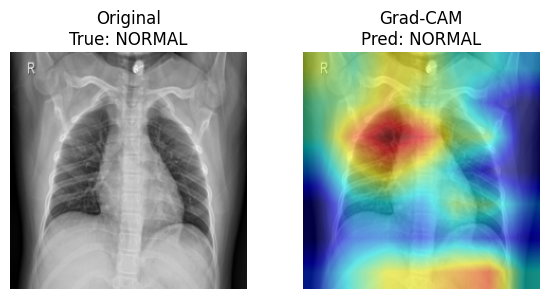

In [30]:
show_gradcam_v2(0)  # show first test image


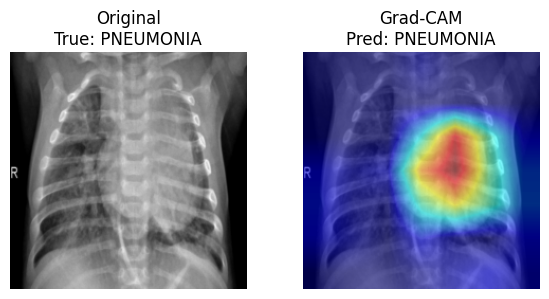

In [31]:
for i, (_, label) in enumerate(test_ds_v2):
    if label == class_names.index("PNEUMONIA"):
        show_gradcam_v2(i)
        break


Create Grad-CAM for ResNet-18 baseline

In [32]:
from pytorch_grad_cam import GradCAM

# Make sure baseline model exists & is in eval mode
resnet18.eval()

# Target layer for Grad-CAM (the last convolution block in ResNet)
target_layer_resnet = resnet18.layer4[-1]
print("ResNet Target Layer:", target_layer_resnet)

# Create Grad-CAM object
cam_resnet = GradCAM(
    model=resnet18,
    target_layers=[target_layer_resnet]
)


ResNet Target Layer: BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [33]:
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

def show_gradcam_resnet(idx):
    """
    Show Grad-CAM heatmap for a test image at index idx using the baseline ResNet-18.
    """
    img_tensor, label = test_ds_v2[idx]   # USE SAME test set for consistency
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        outputs = resnet18(input_tensor)
        _, pred = outputs.max(1)
        pred = pred.item()

    # Convert tensor for CAM overlay
    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img * 0.5 + 0.5).clip(0, 1)  # undo normalization approx

    # Grad-CAM
    grayscale_cam = cam_resnet(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.title(f"Original\nTrue: {class_names[label]}")
    plt.imshow(rgb_img, cmap='gray')
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title(f"ResNet Grad-CAM\nPred: {class_names[pred]}")
    plt.imshow(visualization)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


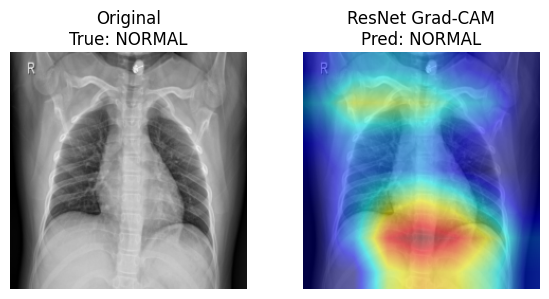

In [34]:
show_gradcam_resnet(0)


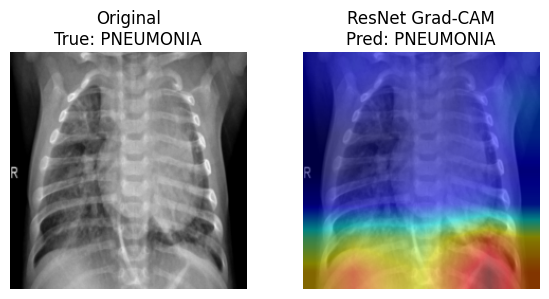

In [35]:
for i, (_, label) in enumerate(test_ds_v2):
    if label == class_names.index("PNEUMONIA"):
        show_gradcam_resnet(i)
        break


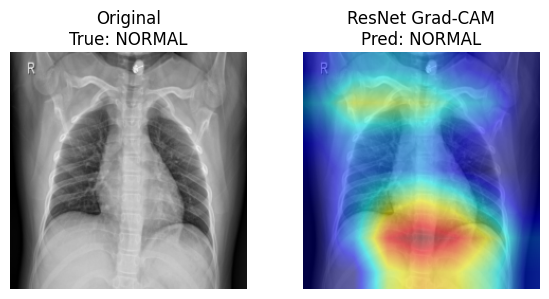

In [36]:
for i, (_, label) in enumerate(test_ds_v2):
    if label == class_names.index("NORMAL"):
        show_gradcam_resnet(i)
        break
